# Matrix Profiling with STUMPY

This notebook builds a first thesis-ready matrix profile workflow using `stumpy` on the processed BTCUSDT 1-minute dataset.

It is structured to answer four practical questions:

1. Which univariate signal should be profiled first?
2. How can a manageable subset be extracted without losing interpretability?
3. Where are the strongest repeated motifs?
4. Where are the largest discords (unusual subsequences)?

## 1. Setup

If needed, install the project dependencies from the repository root:

```bash
pip install -r requirements.txt
```

In [31]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stumpy

plt.style.use("seaborn-v0_8-whitegrid")

In [32]:
# Resolve paths relative to this notebook location.
project_root = Path("../../").resolve()
data_path = project_root / "data" / "processed" / "crypto" / "1min" / "BTCUSDT_1m_processed.parquet"

data_path

WindowsPath('C:/Users/learn/OneDrive/Desktop/Masters Thesis/MastersThesis/data/processed/crypto/1min/BTCUSDT_1m_processed.parquet')

## 2. Load the processed BTCUSDT data

In [33]:
df = pd.read_parquet(data_path)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['timestamp'].min()} -> {df['timestamp'].max()}")

Rows: 4,502,648
Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'log_return', 'pct_return', 'volatility_30m', 'volatility_60m', 'volatility_240m', 'realized_volatility_60m']
Date range: 2017-08-17 04:00:00+00:00 -> 2026-03-15 23:59:00+00:00


## 3. Select a motif-ready signal

For a first matrix profile pass, `log_return` is usually a better starting point than raw price because it reduces trend dominance and makes local pattern comparison more meaningful.

In [34]:
candidate_column = "log_return"

if candidate_column not in df.columns:
    raise KeyError(f"Expected column '{candidate_column}' was not found.")

signal_df = df[["timestamp", "close", candidate_column]].dropna().reset_index(drop=True)
signal_df = signal_df.rename(columns={candidate_column: "signal"})

print(signal_df.head())
print()
print(signal_df["signal"].describe())

                  timestamp    close    signal
0 2017-08-17 04:01:00+00:00  4261.48  0.000000
1 2017-08-17 04:02:00+00:00  4280.56  0.004467
2 2017-08-17 04:03:00+00:00  4261.48 -0.004467
3 2017-08-17 04:04:00+00:00  4261.48  0.000000
4 2017-08-17 04:05:00+00:00  4261.48  0.000000

count    4.502647e+06
mean     6.303645e-07
std      1.142905e-03
min     -7.510582e-02
25%     -3.324153e-04
50%      0.000000e+00
75%      3.331562e-04
max      7.229275e-02
Name: signal, dtype: float64


## 4. Define an analysis subset

Running a matrix profile over the full multi-year 1-minute series can be expensive. The cell below keeps the most recent subset so the first experiment remains fast enough to iterate on.

You can increase `subset_size` later if compute time is acceptable.

In [35]:
subset_size = 30_000
window_size = 60

analysis_df = signal_df.tail(subset_size).copy().reset_index(drop=True)
series = analysis_df["signal"].to_numpy(dtype=float)

if len(series) <= window_size:
    raise ValueError("The subset must be longer than the subsequence window size.")

print(f"Subset length: {len(series):,}")
print(f"Window size: {window_size} observations")
print(f"Profile length will be: {len(series) - window_size + 1:,}")

Subset length: 30,000
Window size: 60 observations
Profile length will be: 29,941


## 5. Compute the matrix profile

`stumpy.stump` returns one row per subsequence. The first column is the matrix profile value and the second column is the index of the nearest-neighbor subsequence.

In [36]:
mp = stumpy.stump(series, m=window_size)

profile = np.asarray(mp[:, 0], dtype=float)
neighbor_idx = np.asarray(mp[:, 1], dtype=int)

print(f"Matrix profile shape: {mp.shape}")
print(f"Minimum profile value: {profile.min():.6f}")
print(f"Maximum profile value: {profile.max():.6f}")

Matrix profile shape: (29941, 4)
Minimum profile value: 4.867613
Maximum profile value: 8.273249


In [37]:
profile_df = pd.DataFrame(
    {
        "subsequence_start": np.arange(len(profile)),
        "timestamp": analysis_df.loc[: len(profile) - 1, "timestamp"].to_numpy(),
        "matrix_profile": profile,
        "nearest_neighbor_start": neighbor_idx,
    }
)

profile_df.head()

,subsequence_start,timestamp,matrix_profile,nearest_neighbor_start
0,0,2026-02-23 04:00:00+00:00,7.501461,5070
1,1,2026-02-23 04:01:00+00:00,7.411641,5071
2,2,2026-02-23 04:02:00+00:00,7.342117,5072
3,3,2026-02-23 04:03:00+00:00,7.365052,5073
4,4,2026-02-23 04:04:00+00:00,7.452818,5074


## 6. Identify top motifs

Low matrix profile values correspond to repeated patterns. The table below collects the best motif candidates after removing overlapping duplicates.

In [38]:
def pick_non_overlapping(indices, window, limit):
    selected = []
    for idx in indices:
        if all(abs(idx - chosen) >= window for chosen in selected):
            selected.append(int(idx))
        if len(selected) == limit:
            break
    return selected


motif_indices = np.argsort(profile)
top_motif_indices = pick_non_overlapping(motif_indices, window_size, limit=5)

motif_table = profile_df.loc[top_motif_indices, ["timestamp", "matrix_profile", "nearest_neighbor_start"]].copy()
motif_table = motif_table.sort_values("matrix_profile").reset_index().rename(columns={"index": "subsequence_start"})
motif_table

,subsequence_start,timestamp,matrix_profile,nearest_neighbor_start
0,23102,2026-03-11 05:02:00+00:00,4.867613,18082
1,18082,2026-03-07 17:22:00+00:00,4.867613,23102
2,29736,2026-03-15 19:36:00+00:00,5.025995,9679
3,9679,2026-03-01 21:19:00+00:00,5.025995,29736
4,9172,2026-03-01 12:52:00+00:00,5.073776,9674


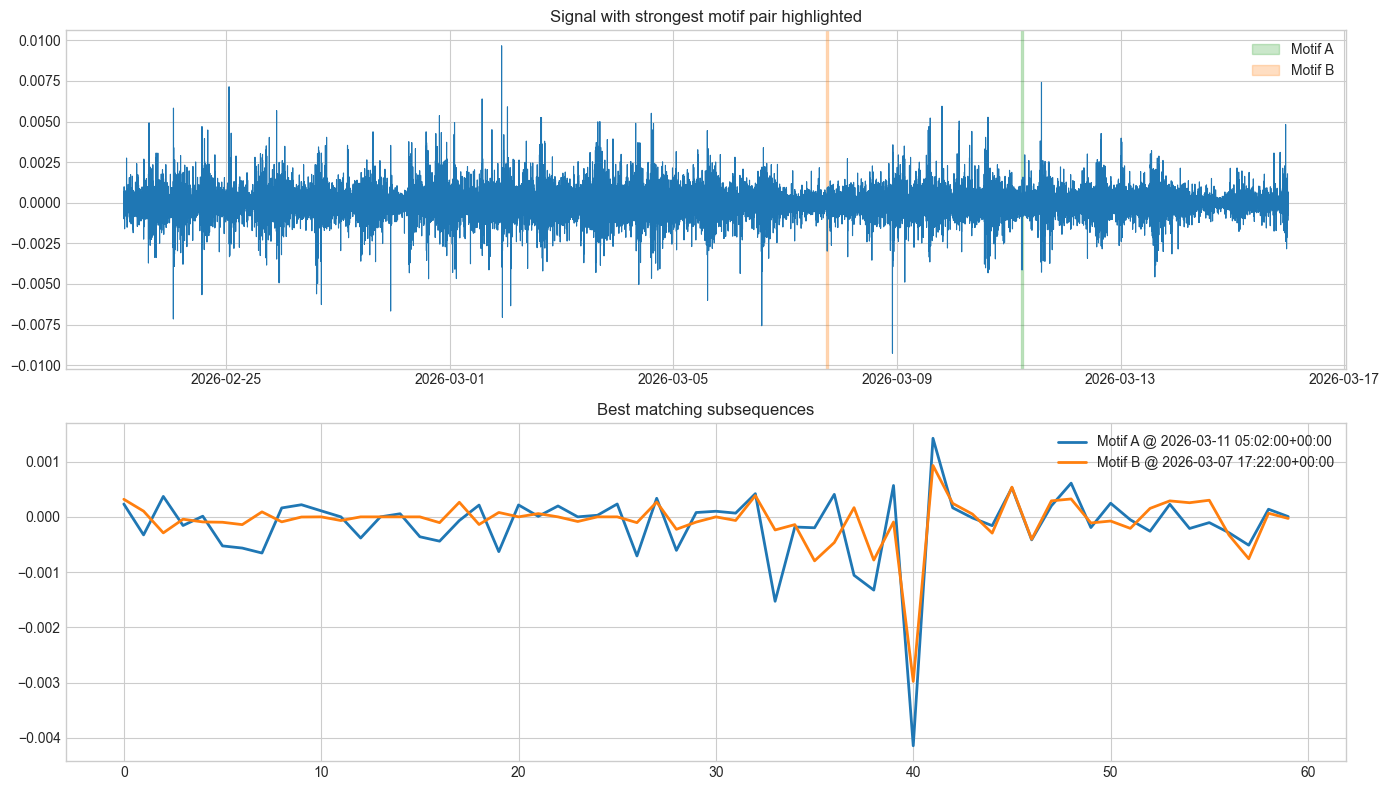

In [39]:
best_motif_idx = top_motif_indices[0]
best_neighbor_idx = int(neighbor_idx[best_motif_idx])

motif_a = series[best_motif_idx : best_motif_idx + window_size]
motif_b = series[best_neighbor_idx : best_neighbor_idx + window_size]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(analysis_df["timestamp"], analysis_df["signal"], color="tab:blue", linewidth=0.8)
axes[0].axvspan(
    analysis_df.loc[best_motif_idx, "timestamp"],
    analysis_df.loc[best_motif_idx + window_size - 1, "timestamp"],
    color="tab:green",
    alpha=0.25,
    label="Motif A",
)
axes[0].axvspan(
    analysis_df.loc[best_neighbor_idx, "timestamp"],
    analysis_df.loc[best_neighbor_idx + window_size - 1, "timestamp"],
    color="tab:orange",
    alpha=0.25,
    label="Motif B",
)
axes[0].set_title("Signal with strongest motif pair highlighted")
axes[0].legend()

axes[1].plot(motif_a, label=f"Motif A @ {analysis_df.loc[best_motif_idx, 'timestamp']}", linewidth=2)
axes[1].plot(motif_b, label=f"Motif B @ {analysis_df.loc[best_neighbor_idx, 'timestamp']}", linewidth=2)
axes[1].set_title("Best matching subsequences")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Identify discords

Large matrix profile values correspond to subsequences that are unusually dissimilar from the rest of the series.

In [40]:
discord_indices = np.argsort(profile)[::-1]
top_discord_indices = pick_non_overlapping(discord_indices, window_size, limit=5)

discord_table = profile_df.loc[top_discord_indices, ["timestamp", "matrix_profile", "nearest_neighbor_start"]].copy()
discord_table = discord_table.sort_values("matrix_profile", ascending=False).reset_index().rename(columns={"index": "subsequence_start"})
discord_table

,subsequence_start,timestamp,matrix_profile,nearest_neighbor_start
0,20504,2026-03-09 09:44:00+00:00,8.273249,19678
1,29335,2026-03-15 12:55:00+00:00,8.244020,13905
2,8572,2026-03-01 02:52:00+00:00,8.232949,21248
3,27800,2026-03-14 11:20:00+00:00,8.231100,12222
4,14132,2026-03-04 23:32:00+00:00,8.224170,11590


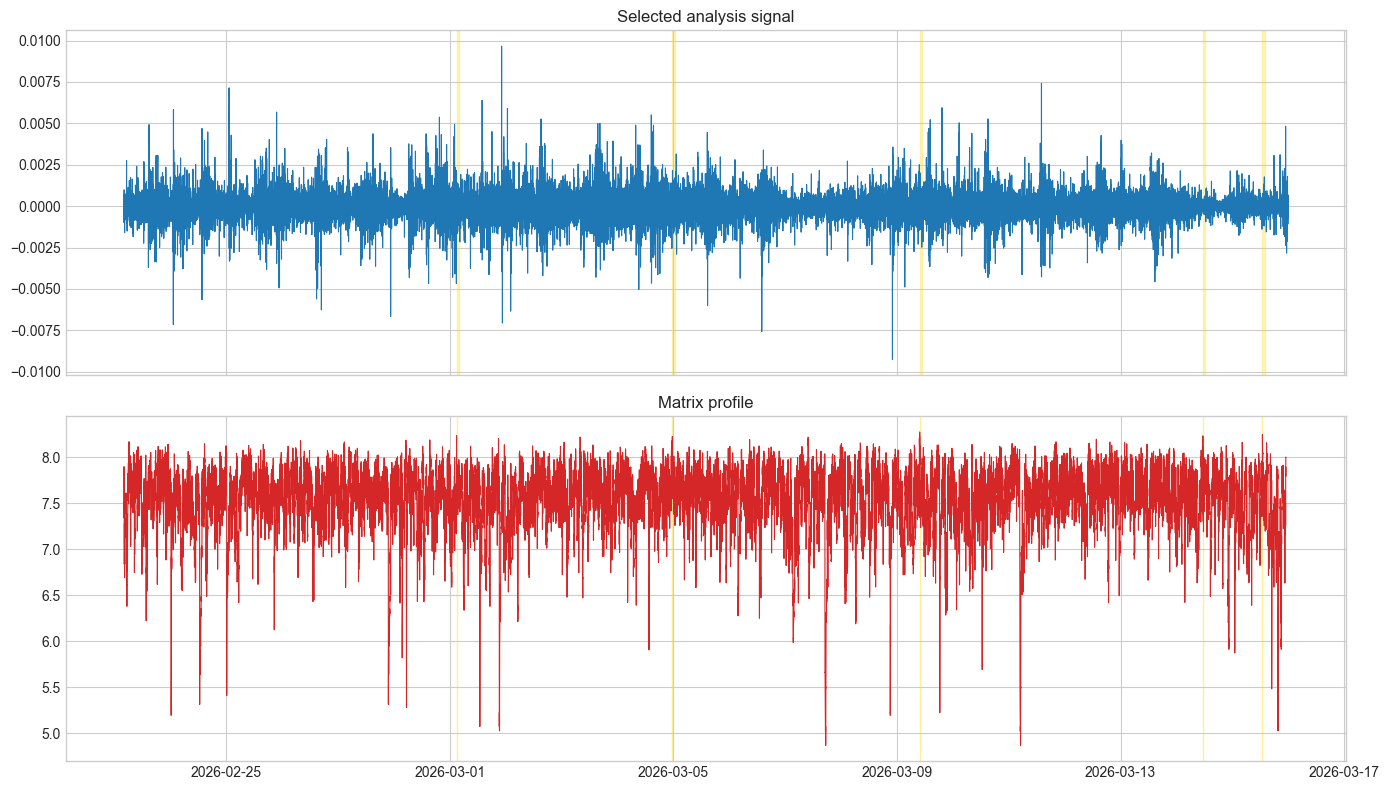

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(analysis_df["timestamp"], analysis_df["signal"], color="tab:blue", linewidth=0.8)
axes[0].set_title("Selected analysis signal")

axes[1].plot(profile_df["timestamp"], profile_df["matrix_profile"], color="tab:red", linewidth=0.8)
axes[1].set_title("Matrix profile")

for idx in top_discord_indices:
    axes[0].axvspan(
        analysis_df.loc[idx, "timestamp"],
        analysis_df.loc[idx + window_size - 1, "timestamp"],
        color="gold",
        alpha=0.25,
    )
    axes[1].axvspan(
        profile_df.loc[idx, "timestamp"],
        profile_df.loc[idx, "timestamp"],
        color="gold",
        alpha=0.4,
    )

plt.tight_layout()
plt.show()

## 8. Interpretation notes

- Motifs with very low profile values indicate repeated local return dynamics.
- Discords mark locally unusual behavior that may correspond to volatility shocks, gaps, or regime transitions.
- For thesis experiments, the next defensible extension is to compare results across multiple window sizes such as 30, 60, 120, and 240 minutes.
- A second extension is to compare BTCUSDT and ETHUSDT on matched calendar windows.

## 9. Matrix profile landscape

The matrix profile can be interpreted as a similarity landscape over time.

- Deep valleys correspond to strong motif candidates
- High peaks correspond to discord candidates

The plot below shows both on the same timeline.

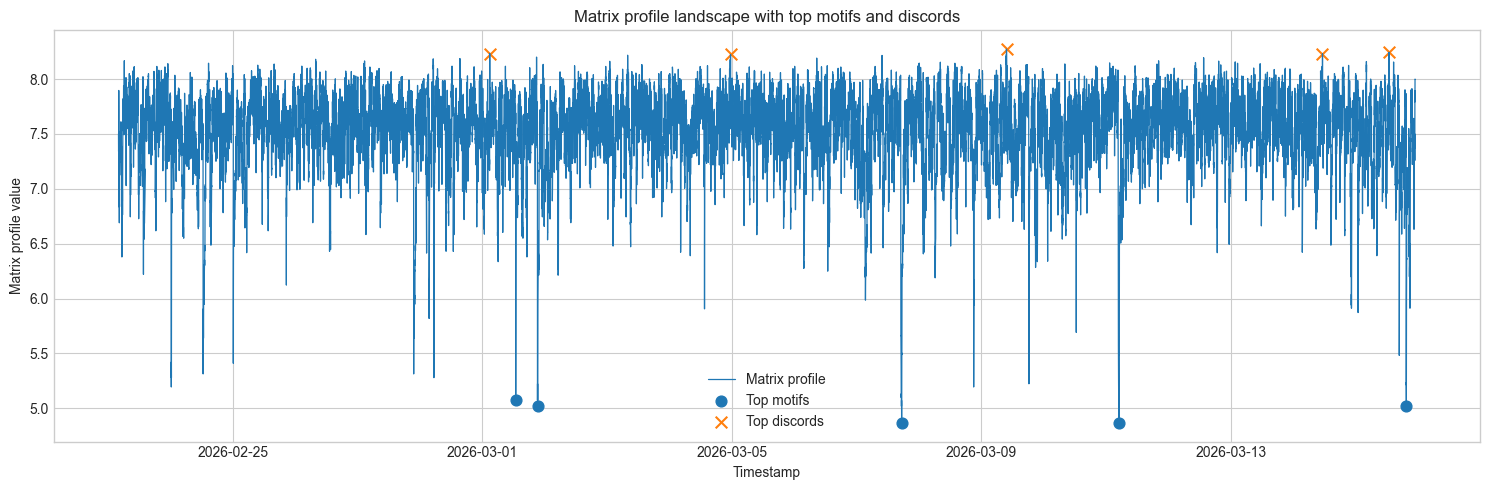

In [42]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(profile_df["timestamp"], profile_df["matrix_profile"], linewidth=0.9, label="Matrix profile")

ax.scatter(
    profile_df.loc[top_motif_indices, "timestamp"],
    profile_df.loc[top_motif_indices, "matrix_profile"],
    marker="o",
    s=60,
    label="Top motifs",
)

ax.scatter(
    profile_df.loc[top_discord_indices, "timestamp"],
    profile_df.loc[top_discord_indices, "matrix_profile"],
    marker="x",
    s=70,
    label="Top discords",
)

ax.set_title("Matrix profile landscape with top motifs and discords")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Matrix profile value")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Top motif candidates on the signal

The next plot places the strongest non-overlapping motif candidates directly on the analysis signal.
This helps check whether repeated structure appears across multiple periods or is concentrated in one local region.

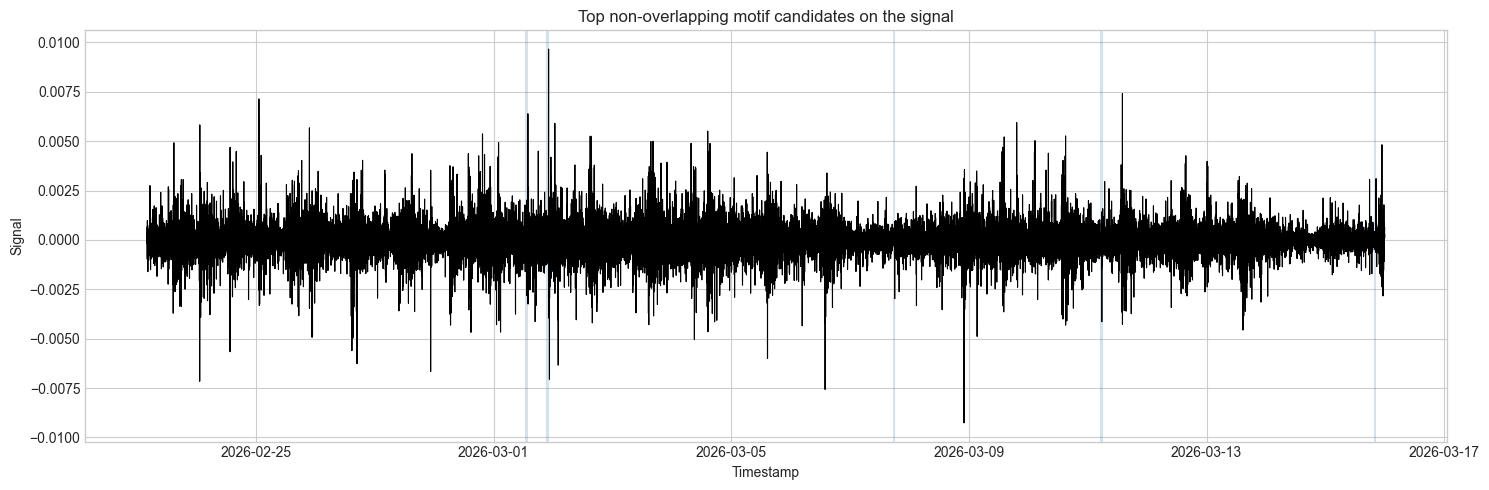

In [43]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(analysis_df["timestamp"], analysis_df["signal"], linewidth=0.8, color="black")

for rank, idx in enumerate(top_motif_indices[:5], start=1):
    ax.axvspan(
        analysis_df.loc[idx, "timestamp"],
        analysis_df.loc[idx + window_size - 1, "timestamp"],
        alpha=0.2,
        label=f"Motif {rank}" if rank == 1 else None,
    )

ax.set_title("Top non-overlapping motif candidates on the signal")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Signal")
plt.tight_layout()
plt.show()

## 11. Top motif pair overlays

Each panel below compares one motif candidate with its nearest neighbor after z-normalization.
This is a stronger visual test of shape similarity than the full-series highlight plot.

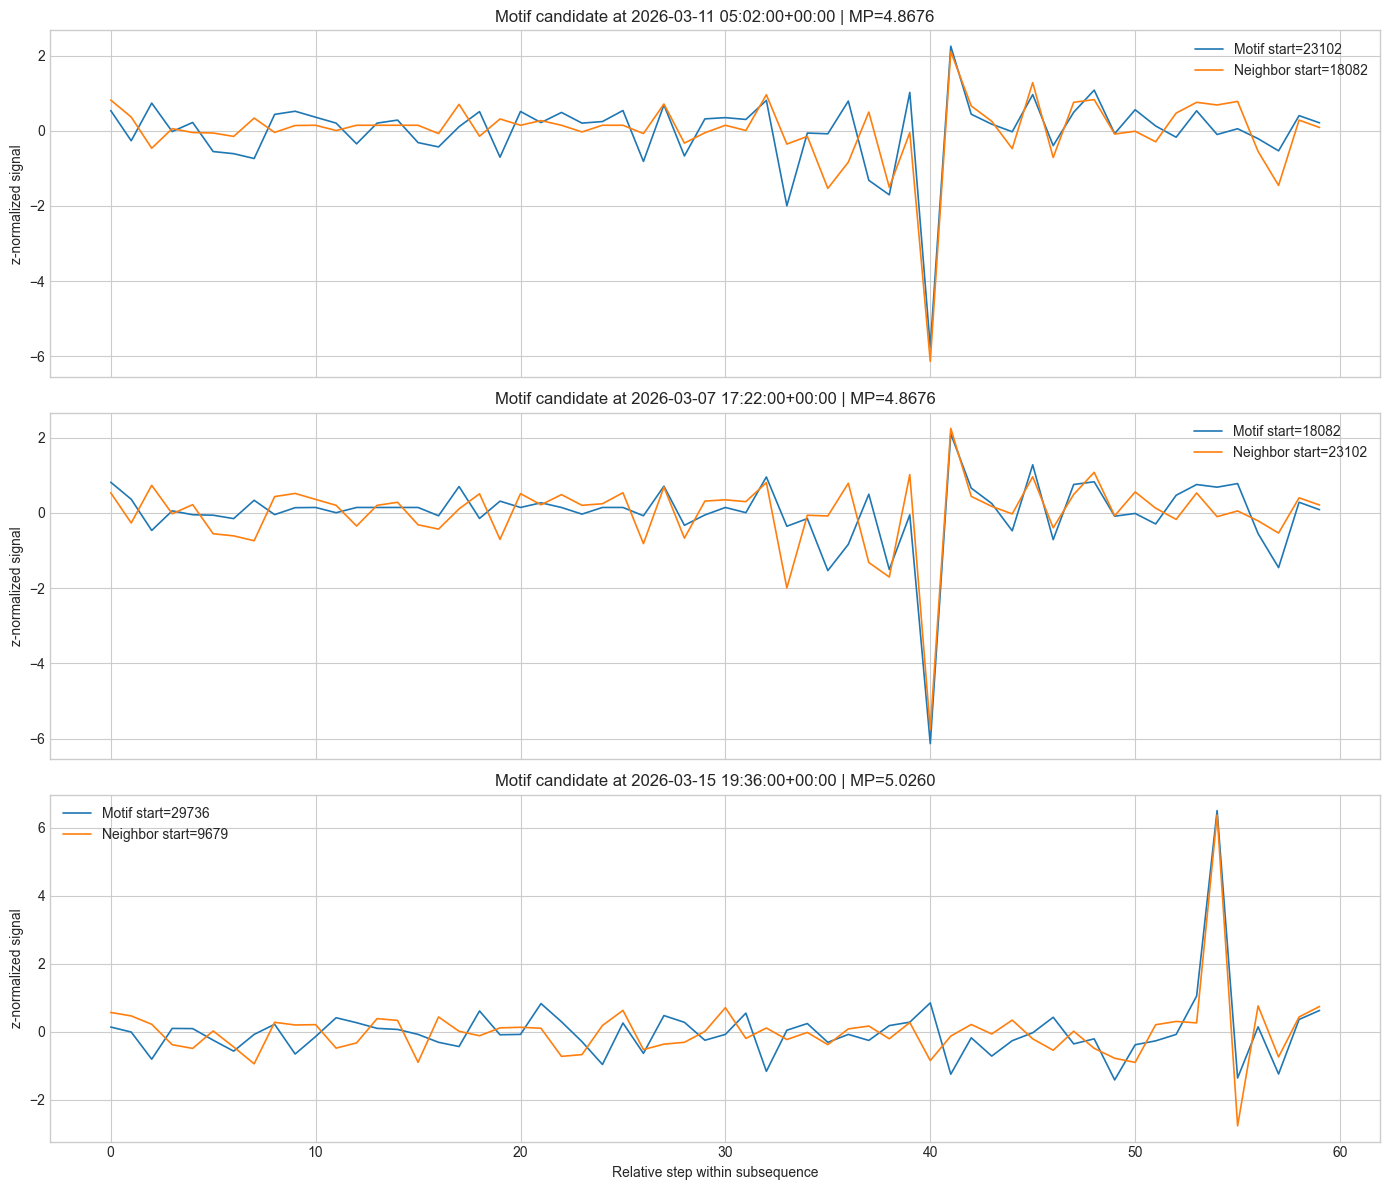

In [44]:
def z_norm(x):
    x = np.asarray(x, dtype=float)
    std = x.std()
    if std == 0:
        return np.zeros_like(x)
    return (x - x.mean()) / std

top_k = min(3, len(top_motif_indices))
fig, axes = plt.subplots(top_k, 1, figsize=(14, 4 * top_k), sharex=True)

if top_k == 1:
    axes = [axes]

for ax, idx in zip(axes, top_motif_indices[:top_k]):
    nn_idx = int(neighbor_idx[idx])

    subseq_a = series[idx : idx + window_size]
    subseq_b = series[nn_idx : nn_idx + window_size]

    ax.plot(z_norm(subseq_a), linewidth=1.2, label=f"Motif start={idx}")
    ax.plot(z_norm(subseq_b), linewidth=1.2, label=f"Neighbor start={nn_idx}")
    ax.set_title(
        f"Motif candidate at {analysis_df.loc[idx, 'timestamp']} "
        f"| MP={profile[idx]:.4f}"
    )
    ax.set_ylabel("z-normalized signal")
    ax.legend()

axes[-1].set_xlabel("Relative step within subsequence")
plt.tight_layout()
plt.show()

## 12. Distribution of profile strengths

This view helps compare where the selected motifs and discords sit relative to the overall profile distribution.

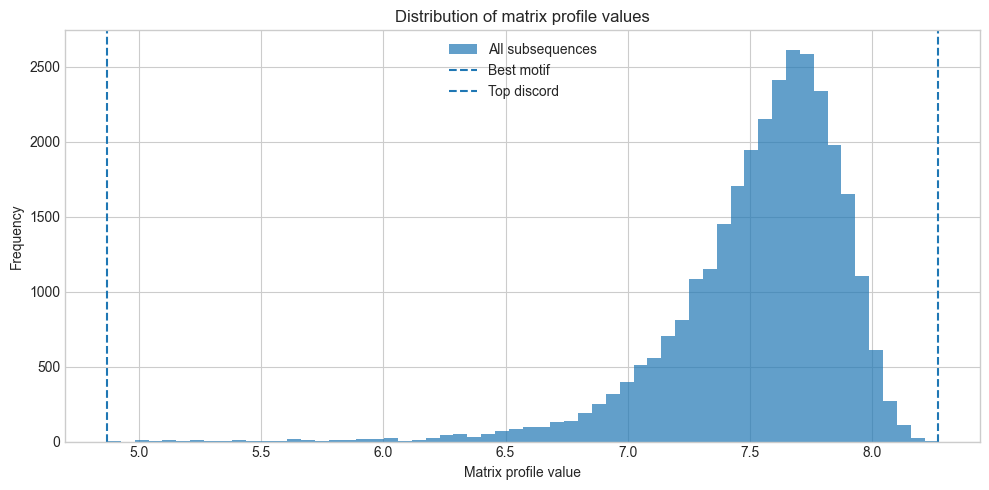

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(profile, bins=60, alpha=0.7, label="All subsequences")
ax.axvline(profile[top_motif_indices[0]], linestyle="--", linewidth=1.5, label="Best motif")
ax.axvline(profile[top_discord_indices[0]], linestyle="--", linewidth=1.5, label="Top discord")

ax.set_title("Distribution of matrix profile values")
ax.set_xlabel("Matrix profile value")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

## 13. Window-size sensitivity

Matrix profile results depend strongly on subsequence length.
The comparison below shows how the profile landscape changes across different window sizes.

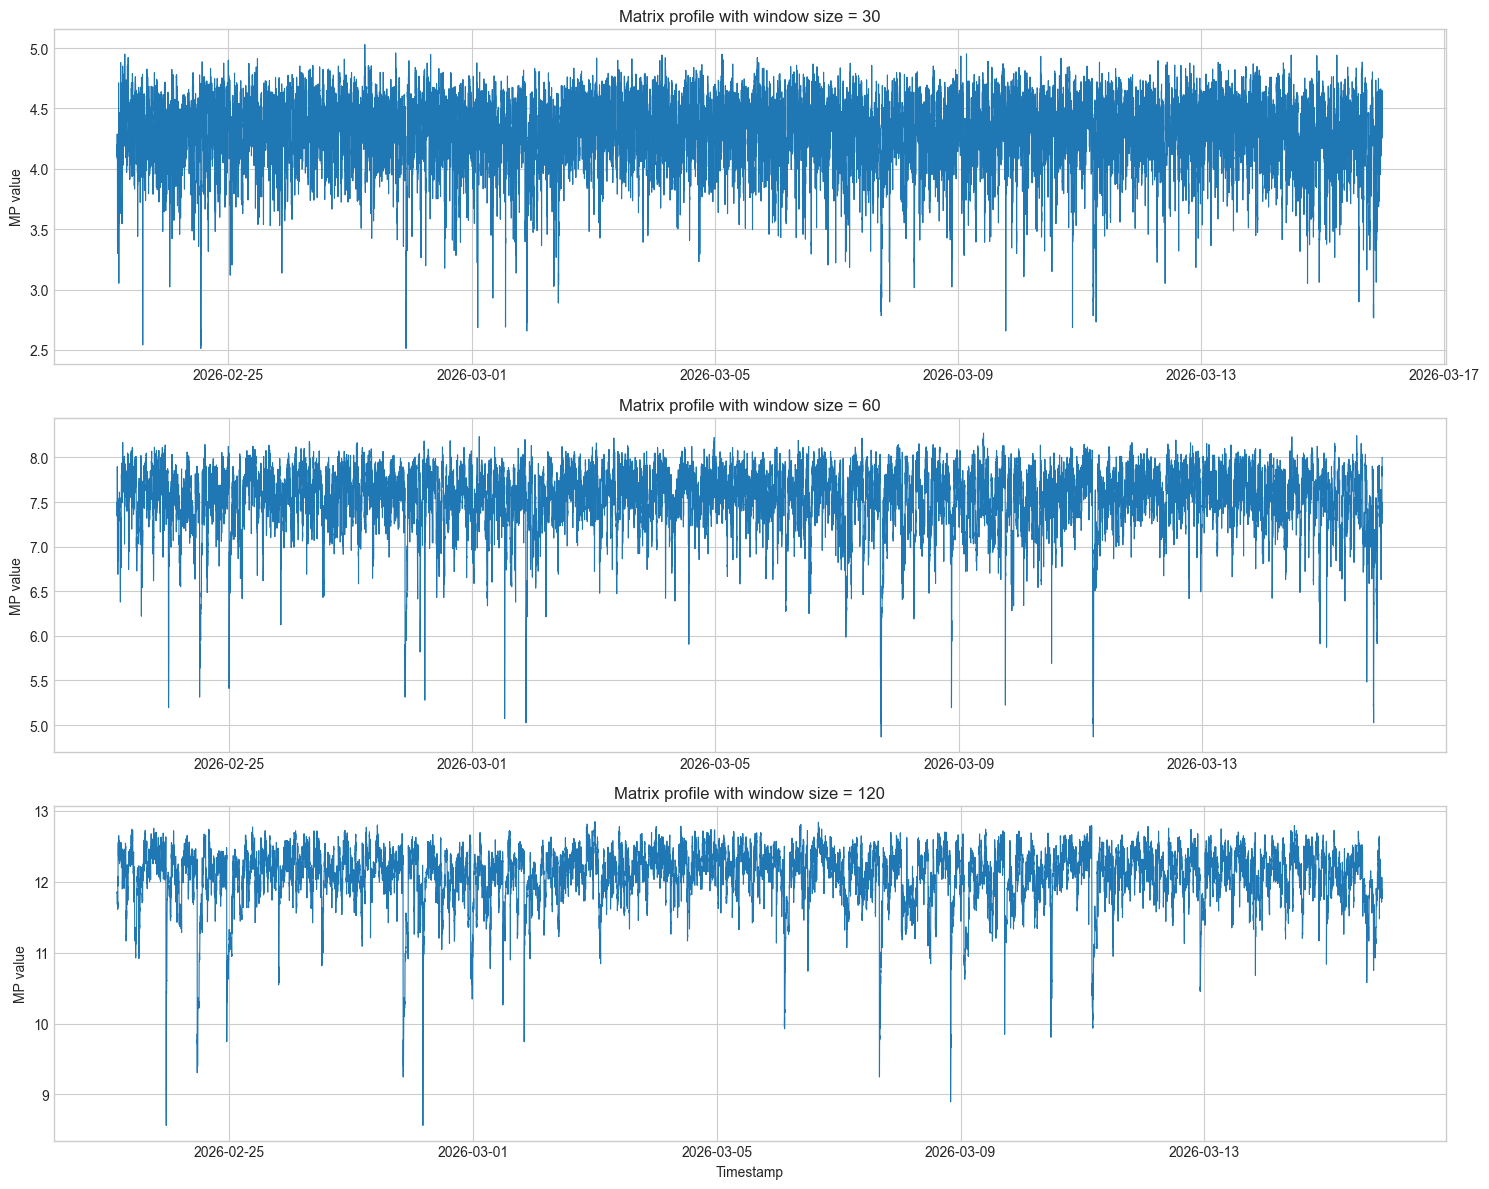

In [46]:
window_sizes = [30, 60, 120]
profiles_by_window = {}

for m in window_sizes:
    if len(series) <= m:
        continue
    mp_m = stumpy.stump(series, m=m)
    profiles_by_window[m] = np.asarray(mp_m[:, 0], dtype=float)

fig, axes = plt.subplots(len(profiles_by_window), 1, figsize=(15, 4 * len(profiles_by_window)), sharex=False)

if len(profiles_by_window) == 1:
    axes = [axes]

for ax, (m, prof) in zip(axes, profiles_by_window.items()):
    ts = analysis_df.loc[: len(prof) - 1, "timestamp"]
    ax.plot(ts, prof, linewidth=0.8)
    ax.set_title(f"Matrix profile with window size = {m}")
    ax.set_ylabel("MP value")

axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

## 14. Candlestick view of the best motif pair

The matrix profile identifies similar subsequences in the signal.
The candlestick view below maps the best motif pair back to actual market behavior for interpretation.

Motif A: 2026-03-11 05:02:00+00:00 -> 2026-03-11 06:01:00+00:00
Motif B: 2026-03-07 17:22:00+00:00 -> 2026-03-07 18:21:00+00:00



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


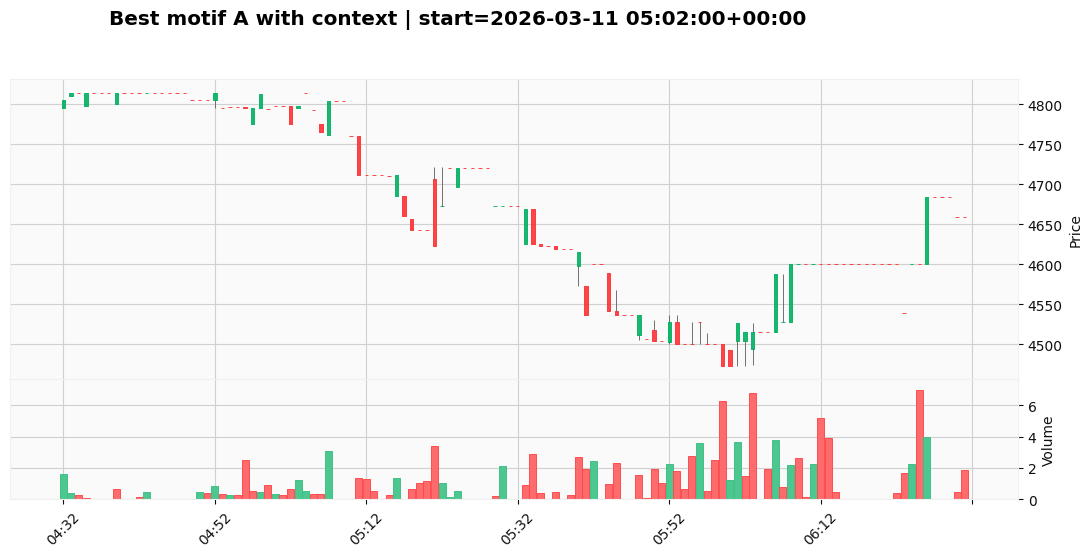

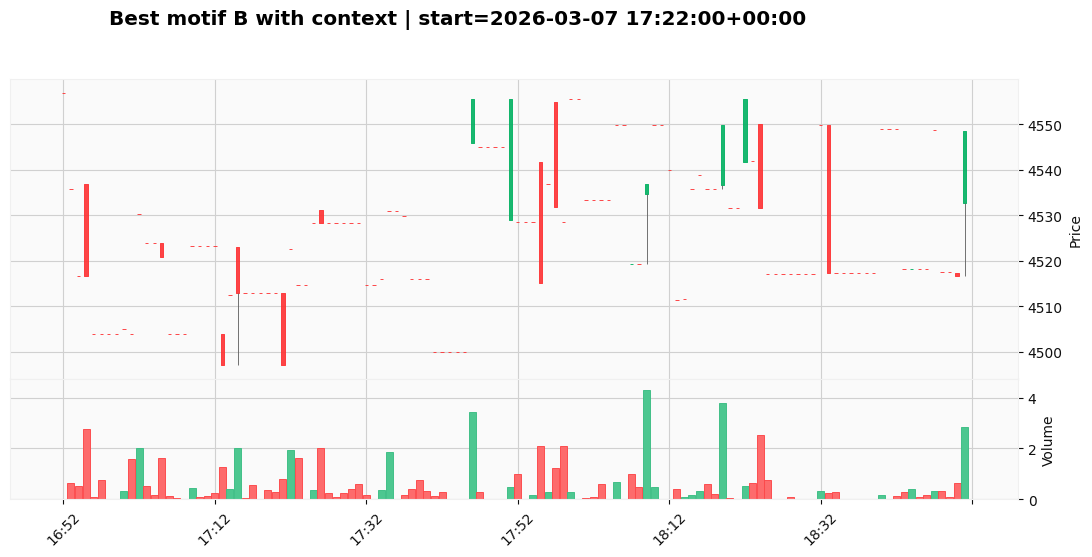

In [48]:
# If needed:
!pip install mplfinance

import mplfinance as mpf

context = 30

def make_ohlc_slice(base_df, start_idx, window, context=30):
    left = max(0, start_idx - context)
    right = min(len(base_df), start_idx + window + context)
    cols = ["timestamp", "open", "high", "low", "close", "volume"]
    out = base_df.loc[left:right - 1, cols].copy()
    out = out.set_index("timestamp")
    return out, left, right

motif_a_ohlc, a_left, a_right = make_ohlc_slice(df, best_motif_idx, window_size, context=context)
motif_b_ohlc, b_left, b_right = make_ohlc_slice(df, best_neighbor_idx, window_size, context=context)

print("Motif A:", analysis_df.loc[best_motif_idx, "timestamp"], "->", analysis_df.loc[best_motif_idx + window_size - 1, "timestamp"])
print("Motif B:", analysis_df.loc[best_neighbor_idx, "timestamp"], "->", analysis_df.loc[best_neighbor_idx + window_size - 1, "timestamp"])

mpf.plot(
    motif_a_ohlc,
    type="candle",
    volume=True,
    figsize=(14, 6),
    title=f"Best motif A with context | start={analysis_df.loc[best_motif_idx, 'timestamp']}",
    style="yahoo"
)

mpf.plot(
    motif_b_ohlc,
    type="candle",
    volume=True,
    figsize=(14, 6),
    title=f"Best motif B with context | start={analysis_df.loc[best_neighbor_idx, 'timestamp']}",
    style="yahoo"
)

## top motif date summary

In [49]:
import pandas as pd
import numpy as np

def subseq_end_timestamp(df, start_idx, window_size, ts_col="timestamp"):
    end_idx = min(start_idx + window_size - 1, len(df) - 1)
    return df.loc[end_idx, ts_col], end_idx

motif_records = []

top_k = min(10, len(top_motif_indices))

for rank, idx in enumerate(top_motif_indices[:top_k], start=1):
    nn_idx = int(neighbor_idx[idx])
    mp_value = float(profile[idx])

    motif_start_time = analysis_df.loc[idx, "timestamp"]
    motif_end_time, motif_end_idx = subseq_end_timestamp(analysis_df, idx, window_size)

    nn_start_time = analysis_df.loc[nn_idx, "timestamp"]
    nn_end_time, nn_end_idx = subseq_end_timestamp(analysis_df, nn_idx, window_size)

    motif_signal = np.asarray(series[idx:idx + window_size], dtype=float)
    nn_signal = np.asarray(series[nn_idx:nn_idx + window_size], dtype=float)

    motif_records.append({
        "rank": rank,
        "motif_start_idx": int(idx),
        "motif_end_idx": int(motif_end_idx),
        "motif_start_time": motif_start_time,
        "motif_end_time": motif_end_time,
        "neighbor_start_idx": int(nn_idx),
        "neighbor_end_idx": int(nn_end_idx),
        "neighbor_start_time": nn_start_time,
        "neighbor_end_time": nn_end_time,
        "matrix_profile_value": mp_value,
        "motif_min_signal": float(np.min(motif_signal)),
        "motif_max_signal": float(np.max(motif_signal)),
        "neighbor_min_signal": float(np.min(nn_signal)),
        "neighbor_max_signal": float(np.max(nn_signal)),
    })

motif_summary_df = pd.DataFrame(motif_records)
motif_summary_df

,rank,motif_start_idx,motif_end_idx,motif_start_time,motif_end_time,neighbor_start_idx,neighbor_end_idx,neighbor_start_time,neighbor_end_time,matrix_profile_value,motif_min_signal,motif_max_signal,neighbor_min_signal,neighbor_max_signal
0,1,23102,23161,2026-03-11 05:02:00+00:00,2026-03-11 06:01:00+00:00,18082,18141,2026-03-07 17:22:00+00:00,2026-03-07 18:21:00+00:00,4.867613,-0.004143,0.001422,-0.002978,0.000929
1,2,18082,18141,2026-03-07 17:22:00+00:00,2026-03-07 18:21:00+00:00,23102,23161,2026-03-11 05:02:00+00:00,2026-03-11 06:01:00+00:00,4.867613,-0.002978,0.000929,-0.004143,0.001422
2,3,29736,29795,2026-03-15 19:36:00+00:00,2026-03-15 20:35:00+00:00,9679,9738,2026-03-01 21:19:00+00:00,2026-03-01 22:18:00+00:00,5.025995,-0.000631,0.003104,-0.003957,0.009664
3,4,9679,9738,2026-03-01 21:19:00+00:00,2026-03-01 22:18:00+00:00,29736,29795,2026-03-15 19:36:00+00:00,2026-03-15 20:35:00+00:00,5.025995,-0.003957,0.009664,-0.000631,0.003104
4,5,9172,9231,2026-03-01 12:52:00+00:00,2026-03-01 13:51:00+00:00,9674,9733,2026-03-01 21:14:00+00:00,2026-03-01 22:13:00+00:00,5.073776,-0.002808,0.006393,-0.001241,0.009664


In [50]:
discord_records = []

top_k_discords = min(10, len(top_discord_indices))

for rank, idx in enumerate(top_discord_indices[:top_k_discords], start=1):
    mp_value = float(profile[idx])

    start_time = analysis_df.loc[idx, "timestamp"]
    end_time, end_idx = subseq_end_timestamp(analysis_df, idx, window_size)

    subseq = np.asarray(series[idx:idx + window_size], dtype=float)

    discord_records.append({
        "rank": rank,
        "discord_start_idx": int(idx),
        "discord_end_idx": int(end_idx),
        "discord_start_time": start_time,
        "discord_end_time": end_time,
        "matrix_profile_value": mp_value,
        "signal_min": float(np.min(subseq)),
        "signal_max": float(np.max(subseq)),
    })

discord_summary_df = pd.DataFrame(discord_records)
discord_summary_df

,rank,discord_start_idx,discord_end_idx,discord_start_time,discord_end_time,matrix_profile_value,signal_min,signal_max
0,1,20504,20563,2026-03-09 09:44:00+00:00,2026-03-09 10:43:00+00:00,8.273249,-0.002481,0.002002
1,2,29335,29394,2026-03-15 12:55:00+00:00,2026-03-15 13:54:00+00:00,8.244020,-0.001200,0.001765
2,3,8572,8631,2026-03-01 02:52:00+00:00,2026-03-01 03:51:00+00:00,8.232949,-0.001664,0.001408
3,4,27800,27859,2026-03-14 11:20:00+00:00,2026-03-14 12:19:00+00:00,8.231100,-0.000512,0.000625
4,5,14132,14191,2026-03-04 23:32:00+00:00,2026-03-05 00:31:00+00:00,8.224170,-0.001633,0.002145


In [52]:
def format_timestamp(x):
    if pd.isna(x):
        return "NA"
    return pd.Timestamp(x).strftime("%Y-%m-%d %H:%M:%S%z")

print("TOP MOTIF SUMMARY")
print("=" * 80)

for _, row in motif_summary_df.iterrows():
    print(
        f"Rank {row['rank']}: "
        f"Motif [{row['motif_start_time']} -> {row['motif_end_time']}] "
        f"(idx {row['motif_start_idx']}:{row['motif_end_idx']}) | "
        f"Neighbor [{row['neighbor_start_time']} -> {row['neighbor_end_time']}] "
        f"(idx {row['neighbor_start_idx']}:{row['neighbor_end_idx']}) | "
        f"MP={row['matrix_profile_value']:.4f}"
    )

print("\nTOP DISCORD SUMMARY")
print("=" * 80)

for _, row in discord_summary_df.iterrows():
    print(
        f"Rank {row['rank']}: "
        f"Discord [{row['discord_start_time']} -> {row['discord_end_time']}] "
        f"(idx {row['discord_start_idx']}:{row['discord_end_idx']}) | "
        f"MP={row['matrix_profile_value']:.4f}"
    )

TOP MOTIF SUMMARY
Rank 1: Motif [2026-03-11 05:02:00+00:00 -> 2026-03-11 06:01:00+00:00] (idx 23102:23161) | Neighbor [2026-03-07 17:22:00+00:00 -> 2026-03-07 18:21:00+00:00] (idx 18082:18141) | MP=4.8676
Rank 2: Motif [2026-03-07 17:22:00+00:00 -> 2026-03-07 18:21:00+00:00] (idx 18082:18141) | Neighbor [2026-03-11 05:02:00+00:00 -> 2026-03-11 06:01:00+00:00] (idx 23102:23161) | MP=4.8676
Rank 3: Motif [2026-03-15 19:36:00+00:00 -> 2026-03-15 20:35:00+00:00] (idx 29736:29795) | Neighbor [2026-03-01 21:19:00+00:00 -> 2026-03-01 22:18:00+00:00] (idx 9679:9738) | MP=5.0260
Rank 4: Motif [2026-03-01 21:19:00+00:00 -> 2026-03-01 22:18:00+00:00] (idx 9679:9738) | Neighbor [2026-03-15 19:36:00+00:00 -> 2026-03-15 20:35:00+00:00] (idx 29736:29795) | MP=5.0260
Rank 5: Motif [2026-03-01 12:52:00+00:00 -> 2026-03-01 13:51:00+00:00] (idx 9172:9231) | Neighbor [2026-03-01 21:14:00+00:00 -> 2026-03-01 22:13:00+00:00] (idx 9674:9733) | MP=5.0738

TOP DISCORD SUMMARY
Rank 1: Discord [2026-03-09 09:44:

In [53]:
def summarize_subsequence_features(base_df, start_idx, window_size):
    end_idx = min(start_idx + window_size - 1, len(base_df) - 1)
    sub = base_df.iloc[start_idx:end_idx + 1].copy()

    out = {
        "n_bars": len(sub),
        "start_time": sub["timestamp"].iloc[0],
        "end_time": sub["timestamp"].iloc[-1],
    }

    if "close" in sub.columns:
        out["close_start"] = float(sub["close"].iloc[0])
        out["close_end"] = float(sub["close"].iloc[-1])
        out["close_return_pct"] = float((sub["close"].iloc[-1] / sub["close"].iloc[0] - 1.0) * 100)

    if "high" in sub.columns and "low" in sub.columns:
        out["price_range_pct"] = float((sub["high"].max() / sub["low"].min() - 1.0) * 100)

    if "volume" in sub.columns:
        out["total_volume"] = float(sub["volume"].sum())
        out["avg_volume"] = float(sub["volume"].mean())

    if "log_return" in sub.columns:
        out["log_return_mean"] = float(sub["log_return"].mean())
        out["log_return_std"] = float(sub["log_return"].std())

    return out

feature_records = []

for _, row in motif_summary_df.iterrows():
    motif_feat = summarize_subsequence_features(df, int(row["motif_start_idx"]), window_size)
    nn_feat = summarize_subsequence_features(df, int(row["neighbor_start_idx"]), window_size)

    feature_records.append({
        "rank": int(row["rank"]),
        "motif_start_time": motif_feat["start_time"],
        "motif_end_time": motif_feat["end_time"],
        "motif_close_return_pct": motif_feat.get("close_return_pct"),
        "motif_price_range_pct": motif_feat.get("price_range_pct"),
        "motif_total_volume": motif_feat.get("total_volume"),
        "motif_log_return_std": motif_feat.get("log_return_std"),
        "neighbor_start_time": nn_feat["start_time"],
        "neighbor_end_time": nn_feat["end_time"],
        "neighbor_close_return_pct": nn_feat.get("close_return_pct"),
        "neighbor_price_range_pct": nn_feat.get("price_range_pct"),
        "neighbor_total_volume": nn_feat.get("total_volume"),
        "neighbor_log_return_std": nn_feat.get("log_return_std"),
        "matrix_profile_value": row["matrix_profile_value"],
    })

motif_feature_df = pd.DataFrame(feature_records)
motif_feature_df

,rank,motif_start_time,motif_end_time,motif_close_return_pct,motif_price_range_pct,motif_total_volume,motif_log_return_std,neighbor_start_time,neighbor_end_time,neighbor_close_return_pct,neighbor_price_range_pct,neighbor_total_volume,neighbor_log_return_std,matrix_profile_value
0,1,2017-09-02 05:02:00+00:00,2017-09-02 06:01:00+00:00,-5.204449,7.624934,66.198433,0.005634,2017-08-29 17:22:00+00:00,2017-08-29 18:21:00+00:00,0.200105,1.234444,36.357128,0.003078,4.867613
1,2,2017-08-29 17:22:00+00:00,2017-08-29 18:21:00+00:00,0.200105,1.234444,36.357128,0.003078,2017-09-02 05:02:00+00:00,2017-09-02 06:01:00+00:00,-5.204449,7.624934,66.198433,0.005634,4.867613
2,3,2017-09-07 02:35:00+00:00,2017-09-07 03:34:00+00:00,0.780065,1.676873,28.385059,0.002863,2017-08-23 21:19:00+00:00,2017-08-23 22:18:00+00:00,-0.170690,2.674579,30.760052,0.002872,5.025995
3,4,2017-08-23 21:19:00+00:00,2017-08-23 22:18:00+00:00,-0.170690,2.674579,30.760052,0.002872,2017-09-07 02:35:00+00:00,2017-09-07 03:34:00+00:00,0.780065,1.676873,28.385059,0.002863,5.025995
4,5,2017-08-23 12:52:00+00:00,2017-08-23 13:51:00+00:00,0.149548,2.021179,95.195412,0.003369,2017-08-23 21:14:00+00:00,2017-08-23 22:13:00+00:00,-0.732776,2.659192,30.324687,0.003024,5.073776
